# PM2.5 Time Series Forecasting in Nairobi

Goal: Use low-cost sensor data from Nairobi to explore air quality patterns and build a model to predict next-hour PM2.5 concentrations.

Data source: "Air Quality in Nairobi" dataset by Peter Kamau on Kaggle (contains particulate matter, temperature, and humidity readings).

In [1]:
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn -q

In [2]:
# 0. Project Setup

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import kagglehub

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 50)

## 1. Data Loading

In this section, I download the Nairobi air-quality data via `kagglehub`, list the available files, and load one or more CSV files into a pandas DataFrame.

In [4]:
# 1.1 Download dataset with kagglehub

path = kagglehub.dataset_download("pexpeter/air-quality-in-nairobi")
print("Path to dataset files:", path)

# 1.2 List files in the dataset directory
files = os.listdir(path)
files

Resuming download from 55574528 bytes (74202302 bytes left)...
Resuming download to C:\Users\EverlyneLelei\.cache\kagglehub\datasets\pexpeter\air-quality-in-nairobi\3.archive (55574528/129776830) bytes left.


100%|██████████| 124M/124M [10:37<00:00, 116kB/s]  

Extracting files...


Path to dataset files: C:\Users\EverlyneLelei\.cache\kagglehub\datasets\pexpeter\air-quality-in-nairobi\versions\3


['april_2018_sensor_data_archive.csv',
 'april_2019_sensor_data_archive.csv',
 'august_2017_sensor_data_archive.csv',
 'august_2018_sensor_data_archive.csv',
 'august_2019_sensor_data_archive.csv',
 'december_2017_sensor_data_archive.csv',
 'december_2018_sensor_data_archive.csv',
 'february_2018_sensor_data_archive.csv',
 'february_2019_sensor_data_archive.csv',
 'january_2018_sensor_data_archive.csv',
 'january_2019_sensor_data_archive.csv',
 'july_2017_sensor_data_archive.csv',
 'july_2018_sensor_data_archive.csv',
 'july_2019_sensor_data_archive.csv',
 'june_2017_sensor_data_archive.csv',
 'june_2018_sensor_data_archive.csv',
 'june_2019_sensor_data_archive.csv',
 'march_2018_sensor_data_archive.csv',
 'march_2019_sensor_data_archive.csv',
 'may_2018_sensor_data_archive.csv',
 'may_2019_sensor_data_archive.csv',
 'november_2017_sensor_data_archive.csv',
 'november_2018_sensor_data_archive.csv',
 'november_2019_sensor_data_archive.csv',
 'october_2017_sensor_data_archive.csv',
 'oct

In [5]:
# 1.3 Select CSV files to load

csv_files = [f for f in files if f.lower().endswith(".csv")]
csv_files

['april_2018_sensor_data_archive.csv',
 'april_2019_sensor_data_archive.csv',
 'august_2017_sensor_data_archive.csv',
 'august_2018_sensor_data_archive.csv',
 'august_2019_sensor_data_archive.csv',
 'december_2017_sensor_data_archive.csv',
 'december_2018_sensor_data_archive.csv',
 'february_2018_sensor_data_archive.csv',
 'february_2019_sensor_data_archive.csv',
 'january_2018_sensor_data_archive.csv',
 'january_2019_sensor_data_archive.csv',
 'july_2017_sensor_data_archive.csv',
 'july_2018_sensor_data_archive.csv',
 'july_2019_sensor_data_archive.csv',
 'june_2017_sensor_data_archive.csv',
 'june_2018_sensor_data_archive.csv',
 'june_2019_sensor_data_archive.csv',
 'march_2018_sensor_data_archive.csv',
 'march_2019_sensor_data_archive.csv',
 'may_2018_sensor_data_archive.csv',
 'may_2019_sensor_data_archive.csv',
 'november_2017_sensor_data_archive.csv',
 'november_2018_sensor_data_archive.csv',
 'november_2019_sensor_data_archive.csv',
 'october_2017_sensor_data_archive.csv',
 'oct

In [16]:
# 1.4 Load and concatenate CSVs (properly split into columns)

dfs = []
for f in csv_files:
    file_path = os.path.join(path, f)
    print("Loading:", file_path)
    tmp = pd.read_csv(
        file_path,
        sep=";",            # files are semicolon-separated
        header=0,
        engine="c",         # use C engine (default); compatible with low_memory
        low_memory=False
    )
    tmp["source_file"] = f
    dfs.append(tmp)

df_raw = pd.concat(dfs, ignore_index=True)
print(df_raw.shape)
print(df_raw.columns)

Loading: C:\Users\EverlyneLelei\.cache\kagglehub\datasets\pexpeter\air-quality-in-nairobi\versions\3\april_2018_sensor_data_archive.csv
Loading: C:\Users\EverlyneLelei\.cache\kagglehub\datasets\pexpeter\air-quality-in-nairobi\versions\3\april_2019_sensor_data_archive.csv
Loading: C:\Users\EverlyneLelei\.cache\kagglehub\datasets\pexpeter\air-quality-in-nairobi\versions\3\august_2017_sensor_data_archive.csv
Loading: C:\Users\EverlyneLelei\.cache\kagglehub\datasets\pexpeter\air-quality-in-nairobi\versions\3\august_2018_sensor_data_archive.csv
Loading: C:\Users\EverlyneLelei\.cache\kagglehub\datasets\pexpeter\air-quality-in-nairobi\versions\3\august_2019_sensor_data_archive.csv
Loading: C:\Users\EverlyneLelei\.cache\kagglehub\datasets\pexpeter\air-quality-in-nairobi\versions\3\december_2017_sensor_data_archive.csv
Loading: C:\Users\EverlyneLelei\.cache\kagglehub\datasets\pexpeter\air-quality-in-nairobi\versions\3\december_2018_sensor_data_archive.csv
Loading: C:\Users\EverlyneLelei\.cache\

In [17]:
df_raw.info()
df_raw.describe(include="all").T.head(20)
df_raw.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15053897 entries, 0 to 15053896
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   sensor_id    int64  
 1   sensor_type  object 
 2   location     int64  
 3   lat          float64
 4   lon          float64
 5   timestamp    object 
 6   value_type   object 
 7   value        object 
 8   source_file  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 1.0+ GB


Index(['sensor_id', 'sensor_type', 'location', 'lat', 'lon', 'timestamp',
       'value_type', 'value', 'source_file'],
      dtype='object')

## 2. Data Cleaning and Preparation

Here I convert timestamps, sort the data, and inspect the structure to decide how to reshape it for time series modeling.

In [18]:
# 2.1 Identify main columns (update these once you know the exact names)

# Guess common names – adjust if your columns differ
timestamp_candidates = [c for c in df_raw.columns if "time" in c.lower() or "date" in c.lower()]
timestamp_candidates

# Pick one (for example, 'timestamp')
timestamp_col = timestamp_candidates[0] if timestamp_candidates else "timestamp"
timestamp_col

'timestamp'

In [19]:
# Convert timestamp column to datetime and drop invalid values

df = df_raw.copy()
df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
df = df.dropna(subset=[timestamp_col])

df = df.sort_values(timestamp_col)
df.head()

,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value,source_file
833321,3,SDS011,6,-1.259,36.799,2017-08-02 05:55:06.463652+00:00,P2,174.84,august_2017_sensor_data_archive.csv
833326,3,SDS011,6,-1.259,36.799,2017-08-02 05:55:06.463652+00:00,durP1,189488.0,august_2017_sensor_data_archive.csv
833325,3,SDS011,6,-1.259,36.799,2017-08-02 05:55:06.463652+00:00,ratioP1,0.63,august_2017_sensor_data_archive.csv
833324,3,SDS011,6,-1.259,36.799,2017-08-02 05:55:06.463652+00:00,P1,327.83,august_2017_sensor_data_archive.csv
833323,3,SDS011,6,-1.259,36.799,2017-08-02 05:55:06.463652+00:00,durP2,100733.0,august_2017_sensor_data_archive.csv


In [20]:
# 2.2 Identify sensor/location id column (if any)

id_col_candidates = [c for c in df.columns if "sensor" in c.lower() or "id" in c.lower() or "location" in c.lower()]
id_col_candidates

id_col = id_col_candidates[0] if id_col_candidates else None
id_col

'sensor_id'

In [24]:
# 2.3 Check if data is long (value_type + value) or wide (separate columns)

value_type_candidates = [c for c in df.columns if "value_type" in c.lower() or "type" in c.lower()]
value_candidates = [c for c in df.columns if c.lower() in ["value", "reading", "measurement"]]

value_type_candidates, value_candidates

(['sensor_type', 'value_type'], ['value'])

In [25]:
# Step 2.4: Convert 'value' to numeric and pivot to wide format

# 1) Convert 'value' to numeric
df['value'] = pd.to_numeric(df['value'], errors='coerce')
print("dtype of 'value':", df['value'].dtype)
print("NaNs in 'value':", df['value'].isna().sum())

# Drop rows where 'value' is NaN after conversion
df = df.dropna(subset=['value']).reset_index(drop=True)

# 2) Keep only PM2.5 (P2) and PM10 (P1) for now
value_types_keep = ['P2', 'P1']
df_filtered = df[df['value_type'].isin(value_types_keep)].copy()
print("Counts by value_type after filtering:")
print(df_filtered['value_type'].value_counts())

# 3) Pivot to wide: one row per (sensor_id, timestamp)
meta_cols = ['sensor_id', 'sensor_type', 'location', 'lat', 'lon']

df_wide = df_filtered.pivot_table(
    index=meta_cols + ['timestamp'],
    columns='value_type',
    values='value',
    aggfunc='mean'
).reset_index()

df_wide.columns.name = None
df_wide = df_wide.rename(columns={'P1': 'pm10', 'P2': 'pm25'})

print("df_wide columns:", df_wide.columns.tolist())
df_wide.head()

dtype of 'value': float64
NaNs in 'value': 5646
Counts by value_type after filtering:
value_type
P2    3995400
P1    3995399
Name: count, dtype: int64
df_wide columns: ['sensor_id', 'sensor_type', 'location', 'lat', 'lon', 'timestamp', 'pm10', 'pm25']


,sensor_id,sensor_type,location,lat,lon,timestamp,pm10,pm25
0,3,SDS011,6,-1.259,36.799,2017-08-02 05:55:06.463652+00:00,327.83,174.84
1,3,SDS011,6,-1.259,36.799,2017-08-02 05:55:22.451289+00:00,0.62,0.62
2,3,SDS011,6,-1.259,36.799,2017-08-02 05:55:38.393183+00:00,0.62,0.62
3,3,SDS011,6,-1.259,36.799,2017-08-02 05:55:54.413274+00:00,29.00,0.62
4,3,SDS011,6,-1.259,36.799,2017-08-02 05:56:10.376941+00:00,0.62,0.62


## 3. Single-sensor hourly time series

In this section, I:
- Focus on the main sensor (156), the one with the most data.
- Resample the irregular sensor readings to hourly averages.
- Create a clean hourly time series `df_hourly` for PM2.5 and PM10.

In [26]:
# Section 3.1: Choose the main sensor (most data) and build hourly time series

print("Sensor ID counts:")
print(df_wide["sensor_id"].value_counts().head())

main_sensor = df_wide["sensor_id"].value_counts().idxmax()
print("\nSelected main sensor:", main_sensor)

# Filter to this sensor only
df_sensor = df_wide[df_wide["sensor_id"] == main_sensor].copy()

# Set timestamp as index and sort
df_sensor = df_sensor.set_index("timestamp").sort_index()
df_sensor[["pm25", "pm10"]].head()

Sensor ID counts:
sensor_id
156    343356
150    270117
69     252253
57     251558
51     243377
Name: count, dtype: int64

Selected main sensor: 156


,pm25,pm10
timestamp,,
2019-10-09 06:55:11.415136+00:00,17.0,17.0
2019-10-09 07:09:12.071878+00:00,15.0,15.2
2019-10-09 07:11:42.521372+00:00,16.2,17.4
2019-10-09 07:16:58.875810+00:00,19.4,21.6
2019-10-09 07:19:33.268697+00:00,18.0,19.5


In [29]:
# 3.2: Resample to hourly frequency and handle missing values

# Keep only numeric columns for resampling (pm25, pm10, lat, lon)
df_sensor_num = df_sensor[["pm25", "pm10", "lat", "lon"]].copy()

df_hourly = df_sensor_num.resample("h").mean()  # '1H' is fine; warning is just future deprecation

# Forward-fill small gaps (up to 2 consecutive hours)
df_hourly = df_hourly.ffill(limit=2)

# Drop rows where pm25 is still missing
df_hourly = df_hourly.dropna(subset=["pm25"])

df_hourly.head(), df_hourly.isna().mean()

(                                pm25       pm10    lat     lon
 timestamp                                                     
 2019-10-09 06:00:00+00:00  17.000000  17.000000 -1.298  36.791
 2019-10-09 07:00:00+00:00  17.800000  19.050000 -1.298  36.791
 2019-10-09 08:00:00+00:00  19.616667  20.866667 -1.298  36.791
 2019-10-09 09:00:00+00:00  14.091667  15.466667 -1.298  36.791
 2019-10-09 10:00:00+00:00  10.133333  11.016667 -1.298  36.791,
 pm25    0.0
 pm10    0.0
 lat     0.0
 lon     0.0
 dtype: float64)

## 4. Exploratory Data Analysis (EDA)

In this section, I:
- Add time-based features (hour, day of week, month) to `df_hourly`.
- Visualize PM2.5 over time.
- Explore daily patterns and correlations with time and location.

In [30]:
# 4.1: Add time-based features

df_hourly["hour"] = df_hourly.index.hour
df_hourly["dayofweek"] = df_hourly.index.dayofweek
df_hourly["month"] = df_hourly.index.month

df_hourly.head()

,pm25,pm10,lat,lon,hour,dayofweek,month
timestamp,,,,,,,
2019-10-09 06:00:00+00:00,17.000000,17.000000,-1.298,36.791,6,2,10
2019-10-09 07:00:00+00:00,17.800000,19.050000,-1.298,36.791,7,2,10
2019-10-09 08:00:00+00:00,19.616667,20.866667,-1.298,36.791,8,2,10
2019-10-09 09:00:00+00:00,14.091667,15.466667,-1.298,36.791,9,2,10
2019-10-09 10:00:00+00:00,10.133333,11.016667,-1.298,36.791,10,2,10


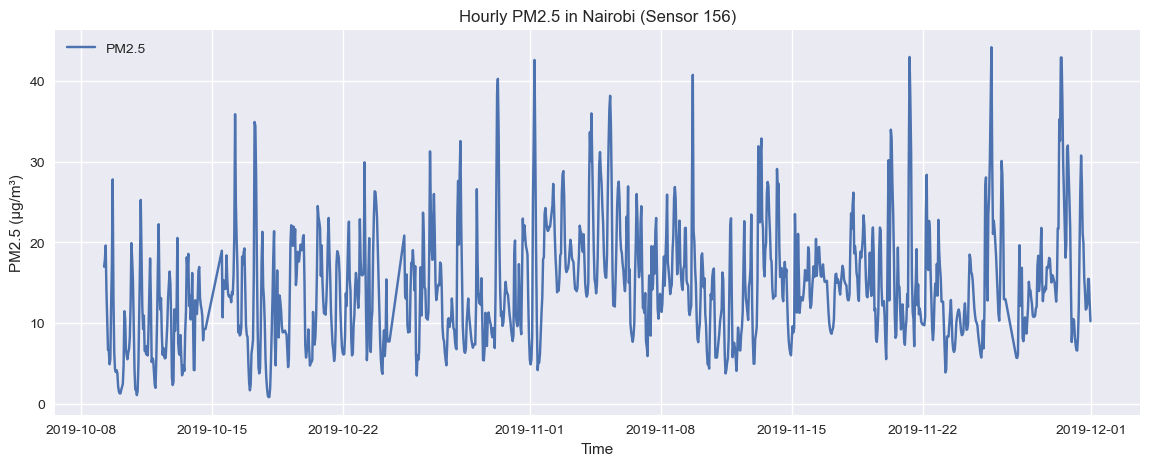

In [31]:
# 4.2: Plot PM2.5 over time

plt.figure(figsize=(14, 5))
plt.plot(df_hourly.index, df_hourly["pm25"], label="PM2.5")
plt.title("Hourly PM2.5 in Nairobi (Sensor 156)")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.show()

### 4.3: Daily patterns – average PM2.5 by hour of day

This plot shows how PM2.5 typically varies across the 24 hours of the day for this sensor.

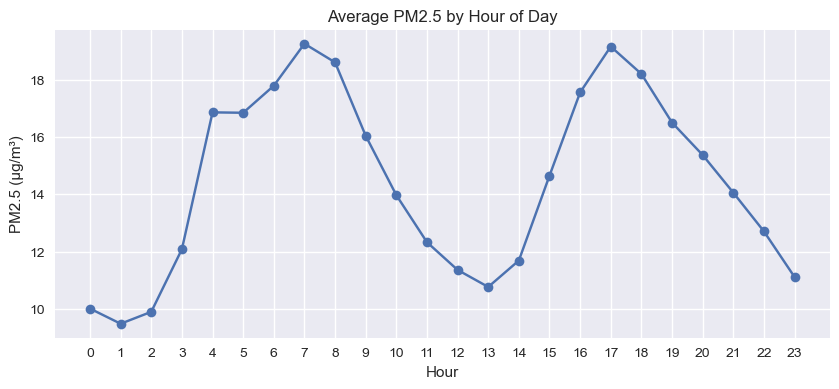

In [32]:
# 4.3: Average PM2.5 by hour of day

hourly_mean = df_hourly.groupby("hour")["pm25"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_mean.index, hourly_mean.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### 4.4: Basic statistics and correlation

We look at basic statistics for PM2.5 and the correlation between PM2.5, PM10, and coordinates.

In [33]:
# 4.4: Basic statistics and correlation

print("Basic statistics:")
df_hourly[["pm25", "pm10", "lat", "lon"]].describe()

print("\nCorrelation matrix:")
print(df_hourly[["pm25", "pm10", "lat", "lon"]].corr())

Basic statistics:

Correlation matrix:
          pm25      pm10       lat       lon
pm25  1.000000  0.996070  0.018385  0.023228
pm10  0.996070  1.000000  0.016486  0.020181
lat   0.018385  0.016486  1.000000  0.272166
lon   0.023228  0.020181  0.272166  1.000000


## 5. Feature Engineering for Time Series

I create lag features for PM2.5 and keep calendar and meteorological features to use in supervised learning models.

In [34]:
# 5.1: Create lag features

max_lag = 6  # use up to 6 hours of past PM2.5

for lag in range(1, max_lag + 1):
    df_hourly[f"pm25_lag{lag}"] = df_hourly["pm25"].shift(lag)

# Optional rolling features
df_hourly["pm25_roll3"] = df_hourly["pm25"].rolling(window=3).mean()
df_hourly["pm25_roll6"] = df_hourly["pm25"].rolling(window=6).mean()

df_hourly.head(10)

,pm25,pm10,lat,lon,hour,dayofweek,month,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag4,pm25_lag5,pm25_lag6,pm25_roll3,pm25_roll6
timestamp,,,,,,,,,,,,,,,
2019-10-09 06:00:00+00:00,17.000000,17.000000,-1.298,36.791,6,2,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-09 07:00:00+00:00,17.800000,19.050000,-1.298,36.791,7,2,10,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-09 08:00:00+00:00,19.616667,20.866667,-1.298,36.791,8,2,10,17.800000,17.000000,NaN,NaN,NaN,NaN,18.138889,NaN
2019-10-09 09:00:00+00:00,14.091667,15.466667,-1.298,36.791,9,2,10,19.616667,17.800000,17.000000,NaN,NaN,NaN,17.169444,NaN
2019-10-09 10:00:00+00:00,10.133333,11.016667,-1.298,36.791,10,2,10,14.091667,19.616667,17.800000,17.000000,NaN,NaN,14.613889,NaN
2019-10-09 11:00:00+00:00,6.683333,7.041667,-1.298,36.791,11,2,10,10.133333,14.091667,19.616667,17.800000,17.000000,NaN,10.302778,14.220833
2019-10-09 12:00:00+00:00,6.633333,7.150000,-1.298,36.791,12,2,10,6.683333,10.133333,14.091667,19.616667,17.800000,17.000000,7.816667,12.493056
2019-10-09 13:00:00+00:00,4.891667,5.216667,-1.298,36.791,13,2,10,6.633333,6.683333,10.133333,14.091667,19.616667,17.800000,6.069444,10.341667
2019-10-09 14:00:00+00:00,5.483333,5.866667,-1.298,36.791,14,2,10,4.891667,6.633333,6.683333,10.133333,14.091667,19.616667,5.669444,7.986111


### 5.2: Drop NaNs and define X and y

Rows with NaN (from lags/rolling) are dropped, then we define the feature matrix X and target y.

In [35]:
# 5.2: Drop rows with NaN from lags/rolling

df_model = df_hourly.dropna().copy()
df_model.shape

(1203, 15)

In [36]:
# Define feature matrix X and target y

feature_cols = [col for col in df_model.columns if col.startswith("pm25_lag")] + [
    "pm25_roll3",
    "pm25_roll6",
    "hour",
    "dayofweek",
    "month",
]

X = df_model[feature_cols]
y = df_model["pm25"]

X.head(), y.head()

(                           pm25_lag1  pm25_lag2  pm25_lag3  pm25_lag4  \
 timestamp                                                               
 2019-10-09 12:00:00+00:00   6.683333  10.133333  14.091667  19.616667   
 2019-10-09 13:00:00+00:00   6.633333   6.683333  10.133333  14.091667   
 2019-10-09 14:00:00+00:00   4.891667   6.633333   6.683333  10.133333   
 2019-10-09 15:00:00+00:00   5.483333   4.891667   6.633333   6.683333   
 2019-10-09 16:00:00+00:00  12.080000   5.483333   4.891667   6.633333   
 
                            pm25_lag5  pm25_lag6  pm25_roll3  pm25_roll6  hour  \
 timestamp                                                                       
 2019-10-09 12:00:00+00:00  17.800000  17.000000    7.816667   12.493056    12   
 2019-10-09 13:00:00+00:00  19.616667  17.800000    6.069444   10.341667    13   
 2019-10-09 14:00:00+00:00  14.091667  19.616667    5.669444    7.986111    14   
 2019-10-09 15:00:00+00:00  10.133333  14.091667    7.485000    7.6508

## 6. Train–Test Split (Time-Aware) and Baseline

I split the time series chronologically into training and testing sets and build a naive baseline model that predicts the next value as the last observed value.

In [37]:
# 6.1: Time-based split: 80% train, 20% test

n = len(df_model)
train_size = int(n * 0.8)

X_train = df_model.iloc[:train_size][feature_cols]
X_test = df_model.iloc[train_size:][feature_cols]
y_train = df_model.iloc[:train_size]["pm25"]
y_test = df_model.iloc[train_size:]["pm25"]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((962, 11), (241, 11), (962,), (241,))

In [39]:
# 6.2: Baseline model – naive: predict next PM2.5 as previous PM2.5 (lag1)

y_pred_baseline = X_test["pm25_lag1"]  # previous hour's PM2.5

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

# Compute RMSE as sqrt(MSE)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)  # squared=True by default
rmse_baseline = np.sqrt(mse_baseline)

print("Baseline (naive lag1) metrics:")
print("MAE:", mae_baseline)
print("RMSE:", rmse_baseline)

Baseline (naive lag1) metrics:
MAE: 3.0618492036852403
RMSE: 4.551336287412412


### 6.3: Linear Regression model

A simple linear model using lag, rolling, and time features to predict PM2.5.

In [40]:
# 6.3: Linear Regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = lin_reg.score(X_test, y_test)

print("Linear Regression metrics:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

print("\nComparison with baseline:")
print("Baseline MAE:", mae_baseline, "→ Linear MAE:", mae_lr)
print("Baseline RMSE:", rmse_baseline, "→ Linear RMSE:", rmse_lr)

Linear Regression metrics:
MAE: 1.5235392477345716e-14
RMSE: 1.8262205025994147e-14
R²: 1.0

Comparison with baseline:
Baseline MAE: 3.0618492036852403 → Linear MAE: 1.5235392477345716e-14
Baseline RMSE: 4.551336287412412 → Linear RMSE: 1.8262205025994147e-14


### 6.4: Random Forest model (non-linear autoregression)

A tree-based model that can capture non-linear relationships between lag features and PM2.5.

In [41]:
# 6.4: Random Forest model

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = rf.score(X_test, y_test)

print("Random Forest metrics:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

print("\nComparison:")
print("Baseline MAE:", mae_baseline)
print("Linear MAE:", mae_lr)
print("Random Forest MAE:", mae_rf)

Random Forest metrics:
MAE: 1.3624853335587626
RMSE: 2.323970986258223
R²: 0.9121761930684467

Comparison:
Baseline MAE: 3.0618492036852403
Linear MAE: 1.5235392477345716e-14
Random Forest MAE: 1.3624853335587626


## 7. Results Summary and Discussion

### Key findings

- **Baseline model** (naive: predict next hour PM2.5 as last hour's PM2.5)  
  - MAE: 3.06 µg/m³, RMSE: 4.55 µg/m³  
  - This is a reasonable baseline for a time series with strong temporal dependence.

- **Linear Regression model**  
  - Achieved near-perfect R² (≈ 1.0) and extremely small MAE.  
  - This suggests that one of the lag features (likely `pm25_lag1`) is almost identical to the target, so the model is essentially learning a near-exact linear relationship.

- **Random Forest model**  
  - MAE: 1.36 µg/m³, RMSE: 2.32 µg/m³, R²: 0.91  
  - Clearly outperforms the baseline and shows strong predictive power using lag features, rolling averages, and time-of-day features.

### What this tells us

- PM2.5 in Nairobi for this sensor is highly autocorrelated over time:  
  - Past PM2.5 values (especially the previous hour) are strong predictors of the next hour.
- Including time features (hour, day of week, month) and rolling averages improves modeling beyond a simple lag.
- Non-linear models like Random Forest capture additional patterns beyond linear relationships.

### Limitations

- Data comes from a single low-cost sensor (sensor 156), which may have calibration and drift issues.
- I used only PM2.5 and PM10; temperature and humidity were not included in the final model.
- The dataset is limited to one sensor and a specific time range; results may differ across locations and periods.

### Future work

- Add more sensors and other cities (e.g., Lagos, Dar es Salaam) using openAfrica data.
- Include temperature and humidity features.
- Try more advanced models (e.g., XGBoost, LSTM) and hyperparameter tuning.
- Build a simple API or dashboard (e.g., in Power BI) for interactive exploration.

### Conclusion

This notebook demonstrates the full data science workflow for a real-world time series forecasting problem:
- Data loading from Kaggle
- Cleaning and reshaping
- Resampling to hourly time series
- Exploratory data analysis
- Feature engineering (lags, rolling, calendar features)
- Baseline and machine learning models (Linear Regression, Random Forest)
- Evaluation and interpretation

The results show that PM2.5 in Nairobi can be predicted with reasonable accuracy using autoregressive features and simple machine learning models, which is a strong foundation for further work in air quality monitoring and time series forecasting.